In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import sklearn

In [2]:
import pandas as pd

customer_360 = pd.read_csv(
    "../data/processed/customer_360_feature_engineered.csv",
    parse_dates=[
        "first_purchase_date",
        "last_purchase_date"
    ]
)

customer_360.shape

(96096, 45)

In [3]:
segmentation_features = [
    "recency_days",
    "total_orders",
    "total_spent",
    "avg_order_value",
    "unique_products",
    "unique_sellers",
    "avg_review_score",
    "freight_cost_ratio",
    "purchase_frequency",
    "customer_lifetime_days"
]

In [4]:
X_segment = customer_360[segmentation_features].copy()

In [5]:
X_segment.shape

(96096, 10)

In [6]:
X_segment.isnull().sum()

recency_days                0
total_orders                0
total_spent                 0
avg_order_value             0
unique_products             0
unique_sellers              0
avg_review_score          716
freight_cost_ratio          0
purchase_frequency          0
customer_lifetime_days      0
dtype: int64

In [7]:
X_segment["avg_review_score"] = X_segment["avg_review_score"].fillna(
    X_segment["avg_review_score"].median()
)               


In [8]:
X_segment.isnull().sum()

recency_days              0
total_orders              0
total_spent               0
avg_order_value           0
unique_products           0
unique_sellers            0
avg_review_score          0
freight_cost_ratio        0
purchase_frequency        0
customer_lifetime_days    0
dtype: int64

In [9]:
# scale the data

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_scaled = scaler.fit_transform(X_segment)

In [10]:
X_scaled.shape

(96096, 10)

In [13]:
from sklearn.cluster import KMeans

interia = []

k_range = range(2,11)

for k in k_range:
    Kmeans = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    Kmeans.fit(X_scaled)
    interia.append(Kmeans.inertia_)

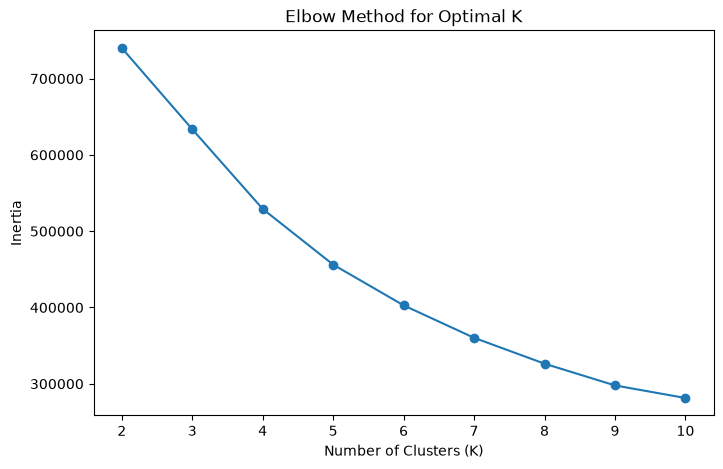

In [16]:
plt.figure(figsize = (8,5))

plt.plot(k_range, interia, marker = 'o')

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Inertia")
plt.title("Elbow Method for Optimal K")
plt.show()

In [28]:
from sklearn.cluster import KMeans 
from sklearn.metrics import silhouette_score
import matplotlib.pyplot as  plt

silhouette_scores = []
K_range = range(2, 11)

# Use a sample to make silhouette calculation faster

sample_size = min(10000, len(X_scaled))

for k in K_range:
    kmeans = KMeans(
        n_clusters= k,
        random_state = 42,
        n_init = 10

    )

    labels = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size = sample_size,
        random_state = 42
    )

    silhouette_scores.append(score)

    print(f"K={k}, silhouette Score = {score:.4f}")

K=2, silhouette Score = 0.7356
K=3, silhouette Score = 0.7291
K=4, silhouette Score = 0.5783
K=5, silhouette Score = 0.3161
K=6, silhouette Score = 0.2612
K=7, silhouette Score = 0.2728
K=8, silhouette Score = 0.2821
K=9, silhouette Score = 0.2933
K=10, silhouette Score = 0.2954


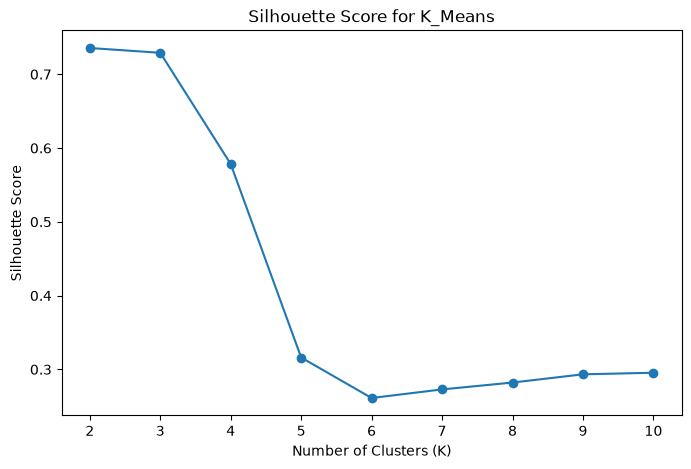

In [30]:
plt.figure(figsize = (8,5))


plt.plot(
    list(K_range),
    silhouette_scores,
    marker = "o"
)

plt.xlabel("Number of Clusters (K)")
plt.ylabel("Silhouette Score")
plt.title("Silhouette Score for K_Means")
plt.show()

In [32]:
# Create the final model

from sklearn.cluster import KMeans

kmeans = KMeans(
    n_clusters = 2,
    random_state = 42,
    n_init = 10
)

customer_360["cluster"] = kmeans.fit_predict(X_scaled)

In [33]:
customer_360["cluster"]

0        1
1        1
2        1
3        1
4        1
        ..
96091    1
96092    1
96093    1
96094    1
96095    1
Name: cluster, Length: 96096, dtype: int32

In [34]:
customer_360["cluster"].value_counts().sort_index()

cluster
0     3113
1    92983
Name: count, dtype: int64

In [35]:
# Profile the two clusters

cluster_profile = customer_360.groupby("cluster")[
    [
        "recency_days",
        "total_orders",
        "total_spent",
        "avg_order_value",
        "unique_products",
        "unique_sellers",
        "avg_review_score",
        "purchase_frequency",
        "customer_lifetime_days"

    ]
].mean().round(2)

In [36]:
cluster_profile

,recency_days,total_orders,total_spent,avg_order_value,unique_products,unique_sellers,avg_review_score,purchase_frequency,customer_lifetime_days
cluster,,,,,,,,,
0,267.39,2.06,318.56,162.80,2.31,2.15,4.06,1.32,83.35
1,288.42,1.00,159.73,159.71,1.02,1.00,4.09,1.00,0.01


In [37]:
# est K = 3, 4, and 5
# We already know:

# K=2 → excellent Silhouette Score
# But K=2 gives only 2 broad customer groups
# We want to see whether 3–5 clusters provide more useful business differentiation.

In [39]:
cluster_results = {}

for k in [3,4,5,6]:
    kmeans_temp = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    labels = kmeans_temp.fit_predict(X_scaled)

    customer_temp = customer_360.copy()
    customer_temp["cluster_temp"] = labels

    profile = customer_temp.groupby("cluster_temp")[
        [
            "recency_days",
            "total_orders",
            "total_spent",
            "avg_order_value",
            "unique_products",
            "unique_sellers",
            "purchase_frequency",
            "customer_lifetime_days"

        ]
    ].mean().round(2)

    cluster_results[k] = profile

    print(f"\n========= K = {k}=========")
    print(profile)




========= K = 3=========
              recency_days  total_orders  total_spent  avg_order_value  \
cluster_temp                                                             
0                   288.38          1.00       160.00           159.99   
1                   303.40          2.03       309.20           159.62   
2                   210.32          2.18       319.73           145.58   

              unique_products  unique_sellers  purchase_frequency  \
cluster_temp                                                        
0                        1.03            1.00                1.00   
1                        2.27            2.11                1.89   
2                        2.30            2.21                0.42   

              customer_lifetime_days  
cluster_temp                          
0                               0.01  
1                              13.22  
2                             202.68  

========= K = 4=========
              recency_days  total_or

In [41]:
from sklearn.metrics import silhouette_score

for k in[2, 3,  4, 5, 6 ]:
    kmeans_temp = KMeans(
        n_clusters = k,
        random_state = 42,
        n_init = 10
    )

    labels = kmeans_temp.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        labels,
        sample_size = 10000,
        random_state = 42
    )

    print(f"K = {k}, silhouette Score = {score:.4f}")


K = 2, silhouette Score = 0.7356
K = 3, silhouette Score = 0.7291
K = 4, silhouette Score = 0.5783
K = 5, silhouette Score = 0.3161
K = 6, silhouette Score = 0.2612


In [ ]:
# why did you choose K = 3?

# "I evaluated different values of K using the Elbow Method and Silhouette Score. "
# "The Silhouette Score was 0.7356 for K=2 and 0.7291 for K=3, so both provided very good cluster separation."
# " Although K=2 had the highest score, it produced only two very broad customer groups,"
# " with one cluster containing about 97% of customers."
# " When I tested K=3, the Silhouette Score decreased only slightly by 0.0065, while the resulting clusters provided more meaningful behavioral differentiation based on order frequency, "
# "spending, and customer lifetime. Therefore, I selected K=3 as a balance between clustering quality and business interpretability."

In [ ]:
# "Why not K=2?"
# "K=2 had the highest Silhouette Score, but its clusters were highly imbalanced—3,113 versus 92,983 customers—and "
# "the segmentation was too broad for customer intelligence."
# " K=3 retained an excellent Silhouette Score while providing an additional meaningful behavioral group."

In [ ]:
# Why not K=4 or K=5?"

# "The Silhouette Score dropped significantly: 
# 0.5783 for K=4 and 0.3161 for K=5. Also, the additional clusters became less distinct and started splitting customers
#  with very similar behavior. Therefore, K=3 offered a better balance.

In [43]:
# Train the final K=3 model

from sklearn.cluster import KMeans

kmeans_final = KMeans(
    n_clusters =3,
    random_state = 42,
    n_init =10
)

customer_360["cluster"] = kmeans_final.fit_predict(X_scaled)

In [45]:
customer_360["cluster"].value_counts().sort_index()

cluster
0    93038
1     1899
2     1159
Name: count, dtype: int64

In [46]:
final_cluster_profile = customer_360.groupby("cluster")[
    [
        "recency_days",
        "total_orders",
        "total_spent",
        "avg_order_value",
        "unique_products",
        "unique_sellers",
        "avg_review_score",
        "purchase_frequency",
        "customer_lifetime_days"
    ]
].mean().round(2)

final_cluster_profile

,recency_days,total_orders,total_spent,avg_order_value,unique_products,unique_sellers,avg_review_score,purchase_frequency,customer_lifetime_days
cluster,,,,,,,,,
0,288.38,1.00,160.00,159.99,1.03,1.00,4.09,1.00,0.01
1,303.40,2.03,309.20,159.62,2.27,2.11,3.97,1.89,13.22
2,210.32,2.18,319.73,145.58,2.30,2.21,4.26,0.42,202.68


In [47]:
# Cluster interpretation

# | Cluster | Main behavior                                                  | Business interpretation       |
# | ------- | -------------------------------------------------------------- | ----------------------------- |
# | **0**   | 1 order, ~160 spent, ~1 product, ~0 lifetime days              | **One-Time Customers**        |
# | **1**   | ~2 orders, ~309 spent, ~2.27 products, high purchase frequency | **Repeat / Active Customers** |
# | **2**   | ~2.18 orders, ~320 spent, ~203 lifetime days, highest reviews  | **Long-Term Customers**       |


In [48]:
# Save meaningful segment names

cluster_names = {
    0: "One-Time Customers",
    1: "Repeat Active Customers",
    2: "Long Term Customers"
}

customer_360["kmeans_segment"] = customer_360["cluster"].map(cluster_names)

In [49]:
customer_360["kmeans_segment"].value_counts()

kmeans_segment
One-Time Customers         93038
Repeat Active Customers     1899
Long Term Customers         1159
Name: count, dtype: int64

In [58]:
customer_360.shape

(96096, 48)

In [59]:
customer_360.drop(columns=["churn"], inplace=True)

In [61]:
del X
del y

NameError: name 'X' is not defined

In [62]:
customer_360.to_csv(
    "../data/processed/customer_360.csv",
    index=False
)